**Mahan Madani - 830504035**

Assignment 2 | Question 2: Image Compression with Autoencoder

# Table of Contents

- [Import libraries and Custom Classes]()
- [Load and Prepare Dataset]()
- [2.1 Hidden Layer Nuerons]()
    - [4 Neurons]()
    - [16 Neurons]()
    - [32 Neurons]()
- [2.2 Image Block Size]()
- [2.3 Backpropagation with Momentum]()

## Import Libraries and Custom Classes

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
from MLP import MLP, LinearLayer
from MLP import MSELoss, CrossEntropyLoss, WeightInitializer
from MLP import ReLU, LeakyReLU, Linear, Sigmoid, Tanh, Softmax
from MLP import shuffle_data, reset_seed, plot_metric_over_epoch, calculate_psnr, GLOBAL_SEED

## Load and Prepare Dataset

In [3]:
IMAGE_DIM = 256

In [4]:
# Retrieve all jpg images as numpy arrays and normalize them
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert("L")  # convert to grayscale
            img = np.array(img, dtype=np.float32)
            img = normalize_pixels(img)
            images.append(img)
    return np.array(images)

# Normalize and denormalize pixel values
def normalize_pixels(image):
    return image / 255.0

def denormalize_pixels(image):
    return (image * 255).astype(np.uint8)

In [5]:
# Divide one image into n*n blocks
def divide_into_blocks(image, n):
    w, h = image.shape
    if w % n != 0 or h % n != 0:
        raise ValueError(f"Image size {image.shape} is not dividable to blocks of size {n}*{n}.")
    blocks = []
    for i in range(0, w, n):
        for j in range(0, h, n):
            block = image[i:i+n, j:j+n]
            blocks.append(block)
    return np.array(blocks)

# Reconstruct the original image from n*n blocks
def restore_image_from_blocks(blocks, img_dim=IMAGE_DIM):
    restored_blocks = np.zeros((img_dim, img_dim), dtype=blocks[0].dtype)
    n = blocks[0].shape[0] 
    block_idx = 0
    for i in range(0, img_dim, n):
        for j in range(0, img_dim, n):
            restored_blocks[i:i+n, j:j+n] = blocks[block_idx]
            block_idx += 1
    return np.array(restored_blocks)

In [6]:
def vectorize_blocks(blocks):
    vectorized_blocks = [block.flatten() for block in blocks]
    return np.array(vectorized_blocks)

def restore_blocks_from_vectors(vectorized_blocks):
    n = int(len(vectorized_blocks[0]) ** 0.5)
    restored = [block.reshape((n, n)) for block in vectorized_blocks]
    return np.array(restored)

In [7]:
# Display a numpy array as an image
def display_image(image, title=''):
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    
def display_and_compare_images(img_original, img_reconstructed):
    plt.figure(figsize=(9, 4))
    
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title('Reconstructed Image')
    
    plt.show()

In [8]:

# Display n*n blocks with space between them
def display_blocks(blocks, img_dim=IMAGE_DIM, gap=1):
    n = blocks[0].shape[0]
    grid_size = img_dim // n
    new_dim = img_dim + (grid_size - 1) * gap
    grid = np.ones((new_dim, new_dim)) 

    idx = 0
    for i in range(grid_size):
        for j in range(grid_size):
            start_x = i * (n + gap)
            start_y = j * (n + gap)
            grid[start_x:start_x+n, start_y:start_y+n] = blocks[idx]
            idx += 1
            
    plt.imshow(grid, cmap='gray')
    plt.axis('off')
    plt.show()

In [9]:
train_path = "Dataset/Q2/TrainSet"
test_path = "Dataset/Q2/TestSet"
train_images = load_images_from_folder(train_path)
test_images = load_images_from_folder(test_path)

### Sample image:

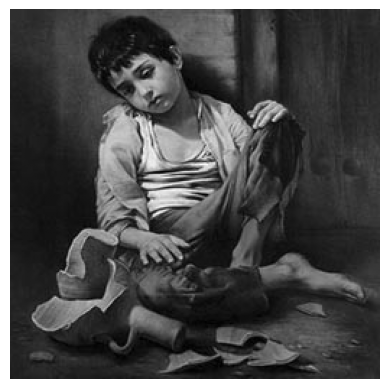

In [10]:
img = train_images[75]
display_image(img)

(64, 32, 32)


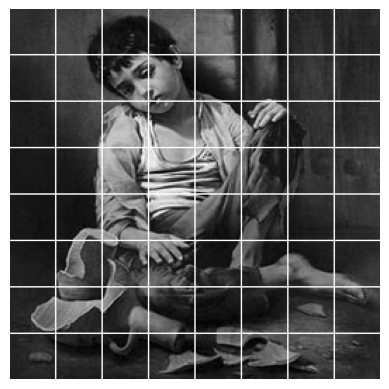

In [11]:
blocks = divide_into_blocks(img, 32)
print(blocks.shape)
display_blocks(blocks)

In [12]:
vectors = vectorize_blocks(blocks)
vectors.shape  # (number of vectors, number of pixels in each vector)

(64, 1024)

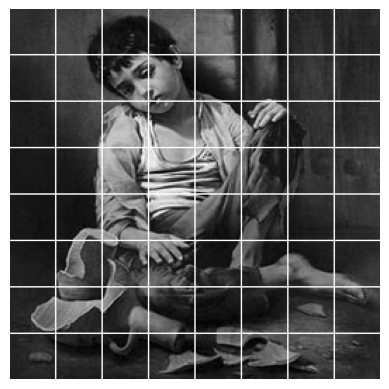

In [13]:
restored_blocks = restore_blocks_from_vectors(vectors)
restored_blocks.shape
display_blocks(restored_blocks)

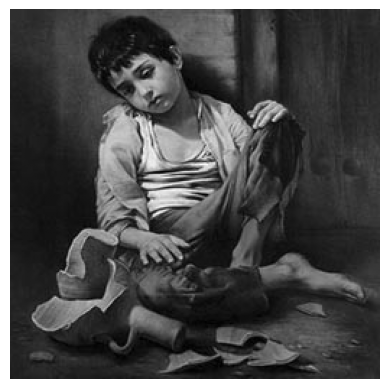

In [14]:
restored_img = restore_image_from_blocks(restored_blocks)
display_image(restored_img)

### Image to Vector Functions

In [15]:
def vectorize_dataset(X, n, img_dim=IMAGE_DIM):
    X = np.array(X)
    img_count = len(X)
    block_count = (img_dim//n)**2  # number of block made from each image
    block_pixel_count = n*n  # number of pixels in each block/vector
    X = [divide_into_blocks(img, n) for img in X]
    X = [vectorize_blocks(blocks) for blocks in X]
    X = np.array(X).reshape(-1, block_pixel_count)

    print(f"{img_count} Images of size {img_dim}*{img_dim} divided to {block_count} Blocks (shape {n}*{n}) per image.")
    print(f"Each block transformed to a vector of size {block_pixel_count}. Total Vectors: {img_count*block_count}.")
    print(f"Model input/output: {X.shape[1]} neurons.\n")
    return X

In [16]:
def convert_predictions_to_images(Y, img_count, n, img_dim=IMAGE_DIM):
    Y = np.array(Y)
    vector_count = len(Y)
    block_count = (img_dim//n)**2  # number of block made from each image
    block_pixel_count = n*n  # number of pixels in each block/vector
    Y = Y.reshape(img_count, block_count, block_pixel_count)
    Y = [restore_blocks_from_vectors(y) for y in Y]
    Y = np.array([restore_image_from_blocks(blocks) for blocks in Y])
    
    print(f"{vector_count} Vectors of size {block_pixel_count} converted to {vector_count} blocks of shape {n}*{n}.")
    print(f"Every {block_count} blocks combined to restore an image of size {img_dim}*{img_dim}.\n")
    return Y

Sample usage:

In [17]:
X_vectorized = vectorize_dataset(train_images, n=32)

91 Images of size 256*256 divided to 64 Blocks (shape 32*32) per image.
Each block transformed to a vector of size 1024. Total Vectors: 5824.
Model input/output: 1024 neurons.



In [18]:
Y_images = convert_predictions_to_images(X_vectorized, img_count=len(train_images), n=32)

5824 Vectors of size 1024 converted to 5824 blocks of shape 32*32.
Every 64 blocks combined to restore an image of size 256*256.



In [19]:
print(train_images.shape)
print(X_vectorized.shape)
print(Y_images.shape)

(91, 256, 256)
(5824, 1024)
(91, 256, 256)


## 2.1 Hidden Layer Neurons

In [36]:
def reconstruct_images(model, vectorized_images, img_count, n):
    reconstructed_images = []
    for vector in vectorized_images:
        reconstructed_images.append(model.forward(vector))

    return convert_predictions_to_images(np.array(reconstructed_images), img_count=img_count, n=n)

In [39]:
def test_with_PSNR(reconstructed_images, target_images, plt_count=5):    
    psnr_sum = 0
    for target_image, reconstructed_image in zip(target_images, reconstructed_images):
        psnr_sum = calculate_psnr(target_image, reconstructed_image)
    psnr_mean = psnr_sum / len(target_images)
    print(f"Mean PSNR: {psnr_mean}\n\n")
    
    # Display and compare a number of images and their respective reconstruction
    for target_image, reconstructed_image in zip(target_images[:plt_count], reconstructed_images[:plt_count]):
        print(f"    PSNR: {calculate_psnr(target_image, reconstructed_image):6f}" )
        display_and_compare_images(img_original=target_image, img_reconstructed=reconstructed_image)
    
    return int(psnr_mean)

In [ ]:
def train_and_evaluate_model(train_images=train_images, test_images=test_images, n=8, hidden_layer_size=4, momentum=0):
    pass

In [21]:
n = 8
train_images_vectorized = vectorize_dataset(train_images, n)
test_images_vectorized  = vectorize_dataset(test_images, n)

91 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 93184.
Model input/output: 64 neurons.

5 Images of size 256*256 divided to 1024 Blocks (shape 8*8) per image.
Each block transformed to a vector of size 64. Total Vectors: 5120.
Model input/output: 64 neurons.



### 4 Neurons

In [ ]:
hidden_layer_size = 4
vector_size = train_images_vectorized.shape[1]

model = MLP(
    layer_sizes=[vector_size, hidden_layer_size, vector_size],
    activations=[Sigmoid(), Linear()],
    loss="mse",
    lr=0.01,
    momentum=0.0,
    weight_type="xavier"
)

print(model)

Multi-Layer Perceptron Details:
Input Size: 64
Output Size: 64
Architecture:
  Layer  1: Linear Block (64, 4),   Activation: Sigmoid
  Layer  2: Linear Block (4, 64),   Activation: Linear
Learning Rate: 0.01
Momentum: 0.0
Weight Initialization Type: xavier



In [23]:
model.train(train_images_vectorized, train_images_vectorized, epochs=50, print_interval=5, batch_size=16,
            test_model=True, X_test=test_images_vectorized, Y_test=test_images_vectorized)

Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.006437,   Test Loss: 0.003231
Epoch   10 /   50,   Train Loss: 0.005825,   Test Loss: 0.002946
Epoch   15 /   50,   Train Loss: 0.005709,   Test Loss: 0.002889
Epoch   20 /   50,   Train Loss: 0.005649,   Test Loss: 0.002859
Epoch   25 /   50,   Train Loss: 0.005612,   Test Loss: 0.002841
Epoch   30 /   50,   Train Loss: 0.005588,   Test Loss: 0.002829
Epoch   35 /   50,   Train Loss: 0.005571,   Test Loss: 0.002820
Epoch   40 /   50,   Train Loss: 0.005558,   Test Loss: 0.002813
Epoch   45 /   50,   Train Loss: 0.005548,   Test Loss: 0.002808
Epoch   50 /   50,   Train Loss: 0.005541,   Test Loss: 0.002804
Training completed in 267.30 seconds.


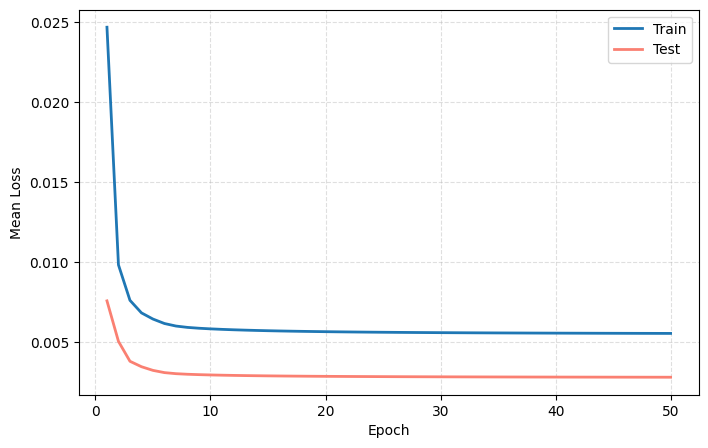

In [24]:
plot_metric_over_epoch(model.train_loss_list, model.test_loss_list)

In [37]:
train_images_reconstructed = reconstruct_images(model, train_images_vectorized, len(train_images), n)
test_images_reconstructed  = reconstruct_images(model, test_images_vectorized, len(test_images), n)

93184 Vectors of size 64 converted to 93184 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.

5120 Vectors of size 64 converted to 5120 blocks of shape 8*8.
Every 1024 blocks combined to restore an image of size 256*256.



In [25]:
train_loss = model.test(train_images_vectorized, train_images_vectorized)
test_loss = model.test(test_images_vectorized, test_images_vectorized)

Mean PSNR: 0.26139158112801214


    PSNR: 16.830547


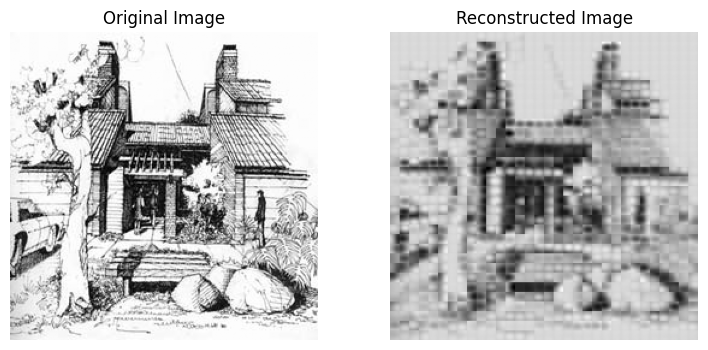

In [40]:
train_psnr = test_with_PSNR(reconstructed_images=train_images_reconstructed, target_images=train_images, plt_count=1)

Mean PSNR: 5.009409889610197


    PSNR: 27.187575


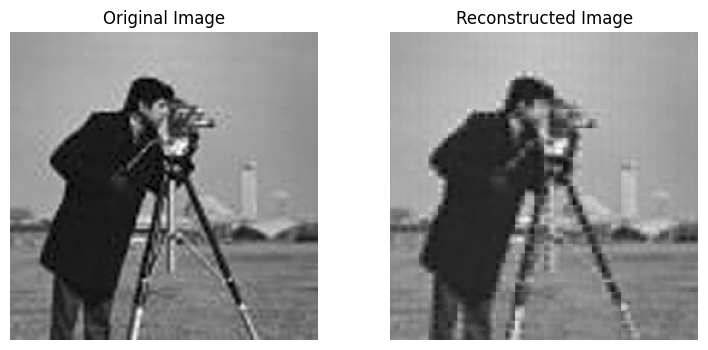

    PSNR: 22.771523


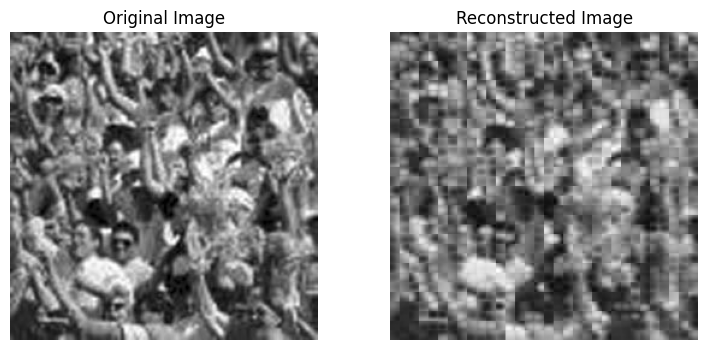

    PSNR: 25.008503


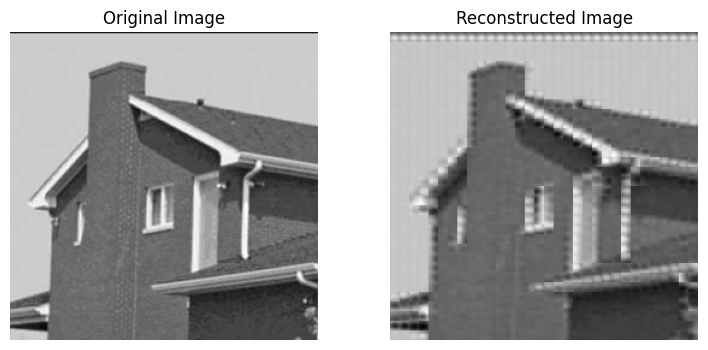

    PSNR: 32.660873


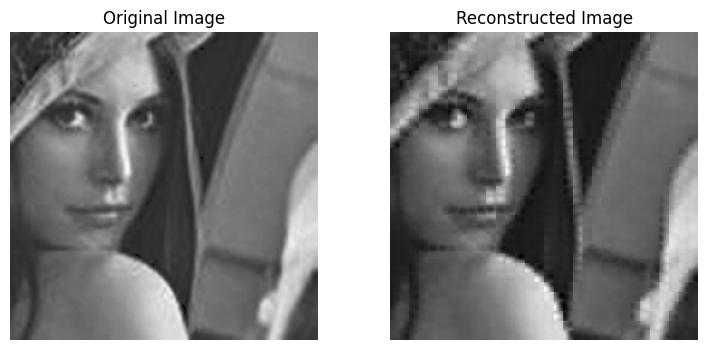

    PSNR: 25.047049


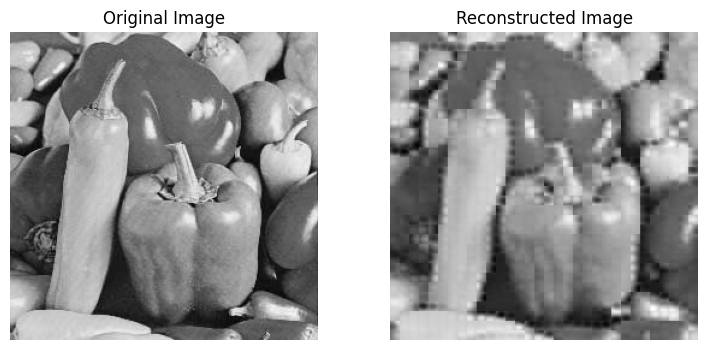

In [41]:
test_psnr = test_with_PSNR(reconstructed_images=test_images_reconstructed, target_images=test_images, plt_count=5)